# Multi-Session PCA Analysis - Class Usage

This notebook demonstrates the `MultiSessionPCA` class for clean, modular PCA analysis.

**Benefits over the original notebook:**
- Clean, reusable code
- Easy parameter tuning
- Simple workflow for rolling window analysis
- All functionality in one place

**Quick Start:**
```python
analyzer = MultiSessionPCA(config)
analyzer.load_data(pickle_path)
analyzer.validate_all_sessions()
analyzer.extract_all_sessions_parallel()
analyzer.concatenate_sessions()
analyzer.subtract_average()
analyzer.fit_and_project()
analyzer.plot_3d_trajectory()
analyzer.save_results('output/')
```

In [1]:
# Imports
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

# Import the class
import importlib
import session_class
importlib.reload(session_class)
from session_class import Session

# Also reload multi_session_pca if needed
import multi_session_pca
importlib.reload(multi_session_pca)
from multi_session_pca import MultiSessionPCA

print("✓ Imports loaded successfully!")

✓ Imports loaded successfully!


## Example 1: Basic Usage with Default Configuration

In [2]:
# Initialize with default configuration
analyzer = MultiSessionPCA()

# Check default config
print("Default Configuration:")
print(f"  Epoch: {analyzer.config['epok']} ms")
print(f"  Bin size: {analyzer.config['bin_size']} ms")
print(f"  Smoothing: {analyzer.config['smooth_ker_size']} ms")
print(f"  PCA components: {analyzer.config['n_pca_components']}")
print(f"  Subtract average: {analyzer.config['subtract_average']}")

Default Configuration:
  Epoch: [-50, 500] ms
  Bin size: 1 ms
  Smoothing: 25 ms
  PCA components: 5
  Subtract average: True


In [3]:
# Load data
base_path = Path.cwd().parent / 'data' / 'unified_cell_trial_data'
pickle_file = base_path / 'msn_fiona_cell_trial_data.pkl'

analyzer.load_data(pickle_file)

Loading data from: /Users/barak/Projects/population_analysis/data/unified_cell_trial_data/msn_fiona_cell_trial_data.pkl
✓ Database loaded: 770,705 cell-trial combinations
  Total sessions: 60
  Total unique cells: 1414


In [4]:
# Validate sessions
analyzer.validate_all_sessions(verbose=True)

✓ Session statistics computed for 60 sessions
  Excluded sessions: 1
  Candidate sessions: 59
Validating sessions...
--------------------------------------------------------------------------------
Cell 2134 removed from session fi211110a.
Dropped 1 cell with incomplete trial type or directional data.
✓ fi211110a: Valid (84 cells)
✓ fi211026a: Valid (76 cells)
✓ fi211102a: Valid (71 cells)
✓ fi211111a: Valid (64 cells)
✓ fi211025a: Valid (63 cells)
✓ fi211104a: Valid (59 cells)
✓ fi211109a: Valid (59 cells)
✓ fi211122a: Valid (58 cells)
✓ fi211115a: Valid (53 cells)
✓ fi211118a: Valid (52 cells)
✓ fi211020a: Valid (49 cells)
✓ fi211108a: Valid (42 cells)
✓ fi211018a: Valid (40 cells)
✓ fi211123a: Valid (36 cells)
✓ fi211019a: Valid (34 cells)
✓ fi211125a: Valid (34 cells)
✓ fi211014a: Valid (32 cells)
✓ fi211017a: Valid (32 cells)
✓ fi211103a: Valid (29 cells)
✓ fi211021a: Valid (27 cells)
✓ fi211124a: Valid (26 cells)
✓ fi210907a: Valid (25 cells)
✓ fi210909a: Valid (23 cells)
✓ fi211

In [5]:
# Extract PSTH matrices (parallel processing)
sessions_PSTHs = analyzer.extract_all_sessions_parallel(pickle_path=pickle_file)

Extracting PSTHs from 40 sessions using 6 workers...
  Using pre-loaded data (efficient mode)
  Subtract average: True
--------------------------------------------------------------------------------
Cell 2134 removed from session fi211110a.
Dropped 1 cell with incomplete trial type or directional data.


Processing:   2%|▎         | 1/40 [00:10<07:05, 10.91s/it]

[1/40] ✓ fi211025a: 63 cells


Processing:   5%|▌         | 2/40 [00:11<02:55,  4.63s/it]

[2/40] ✓ fi211102a: 71 cells


...

Processing:  98%|█████████▊| 39/40 [00:40<00:00,  4.49it/s]

[38/40] ✓ fi210901a: 12 cells
[39/40] ✓ fi210815a: 11 cells


Processing: 100%|██████████| 40/40 [00:41<00:00,  1.03s/it]

[40/40] ✓ fi210809a: 10 cells


--------------------------------------------------------------------------------
✓ Extraction complete: 40/40 successful


In [6]:
# Prepare data for PCA
analyzer.concatenate_sessions()
analyzer.subtract_average()

Concatenating PSTH matrices across sessions...
✓ Concatenation complete:
  GO Left: (1322, 550)
  GO Right: (1322, 550)
  STOP Left: (1322, 550)
  STOP Right: (1322, 550)
Subtracting average PSTH from all conditions...
  Average PSTH shape: (1322, 550)
  Mean: -6.7823, Std: 7.9340
✓ Average PSTH subtracted


In [7]:
# Fit PCA and project all conditions
analyzer.fit_and_project()

✓ PCA matrix prepared: (1322, 1100)
  (n_cells=1322, n_features=1100)
Fitting PCA with 5 components...
✓ PCA fitted
  PC1: 48.74% variance
  PC2: 25.66% variance
  PC3: 9.56% variance
  PC4: 5.73% variance
  PC5: 3.60% variance
  Total: 93.29%
Projecting all conditions onto PC space...
✓ Projections complete:
  GO Left: (5, 550)
  GO Right: (5, 550)
  STOP Left: (5, 550)
  STOP Right: (5, 550)


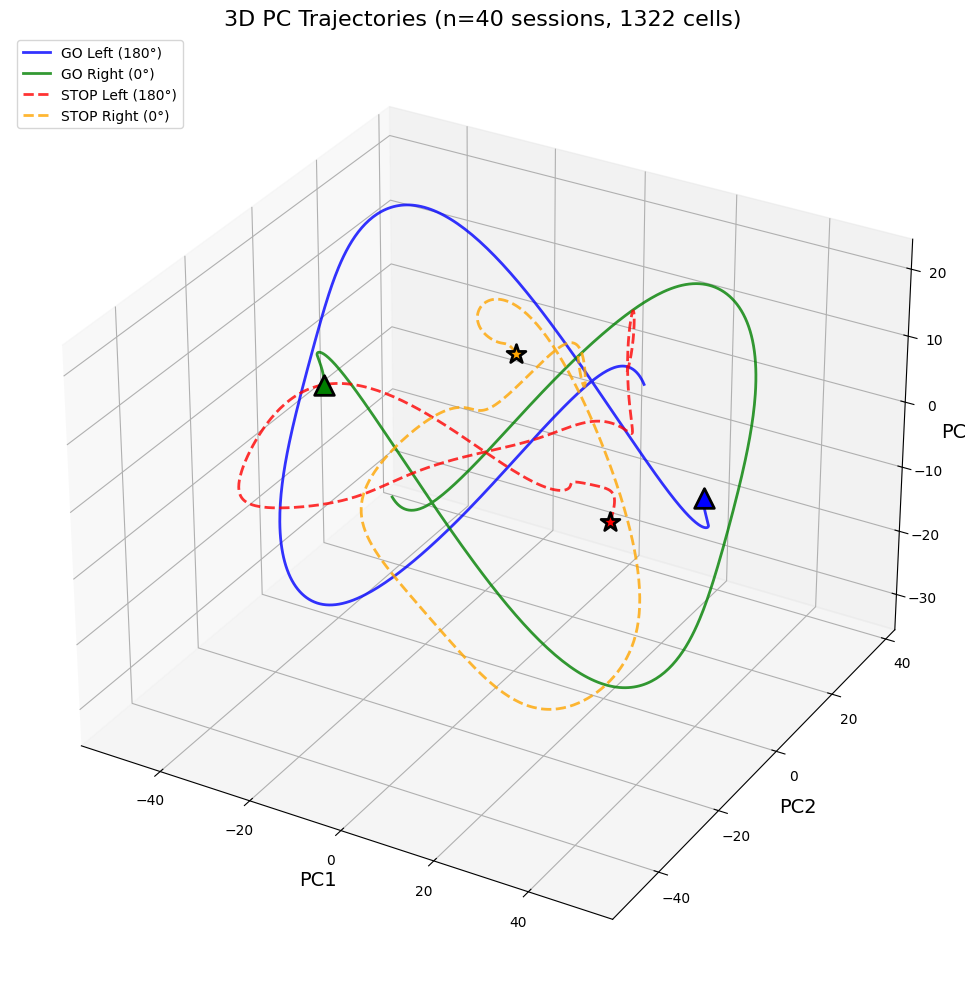

(<Figure size 1200x1000 with 1 Axes>,
 <Axes3D: title={'center': '3D PC Trajectories (n=40 sessions, 1322 cells)'}, xlabel='PC1', ylabel='PC2', zlabel='PC3'>)

In [8]:
# Visualize results
analyzer.plot_3d_trajectory()

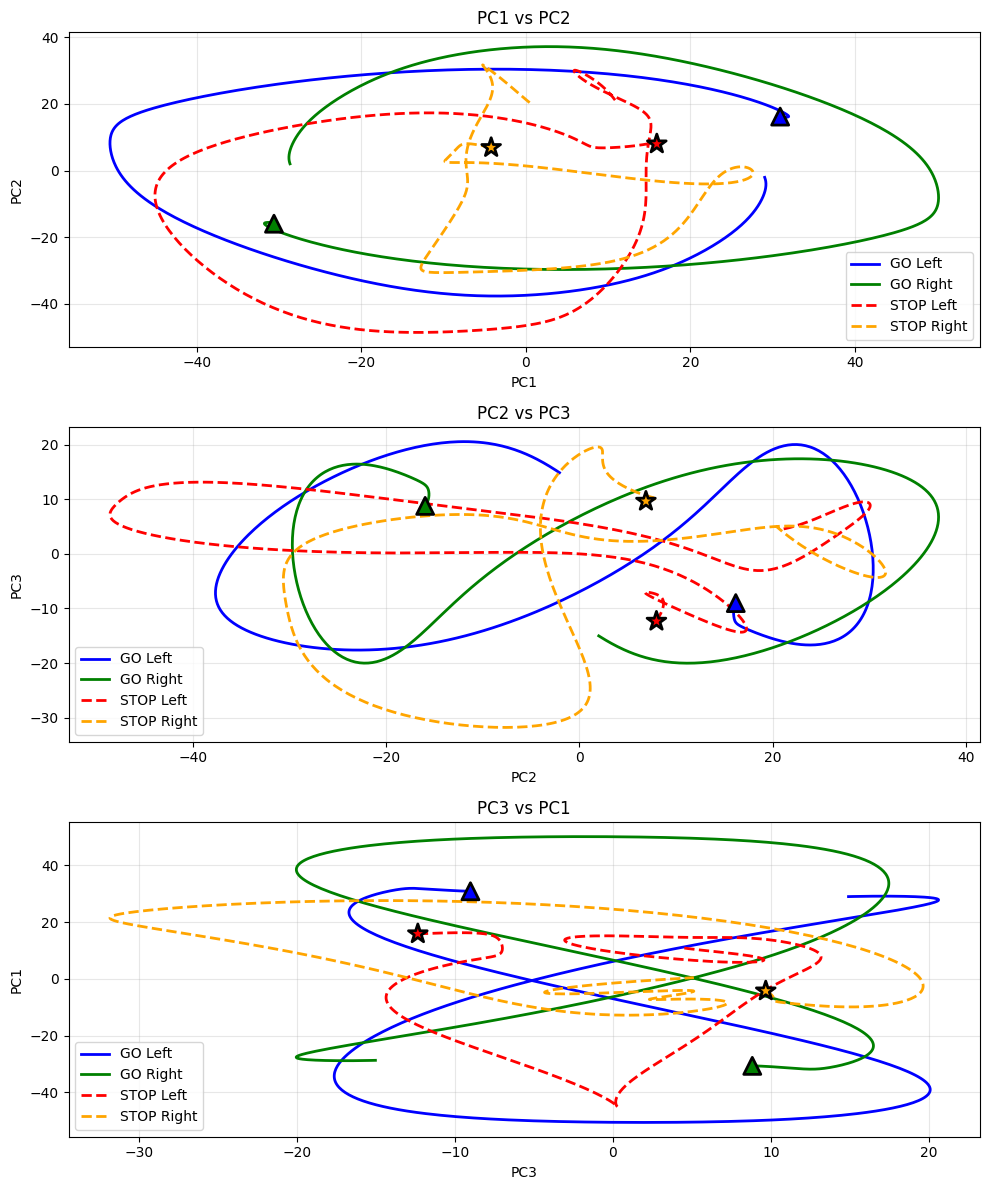

(<Figure size 1000x1200 with 3 Axes>,
 array([<Axes: title={'center': 'PC1 vs PC2'}, xlabel='PC1', ylabel='PC2'>,
        <Axes: title={'center': 'PC2 vs PC3'}, xlabel='PC2', ylabel='PC3'>,
        <Axes: title={'center': 'PC3 vs PC1'}, xlabel='PC3', ylabel='PC1'>],
       dtype=object))

In [9]:
# 2D projections grid
analyzer.plot_2d_grid()

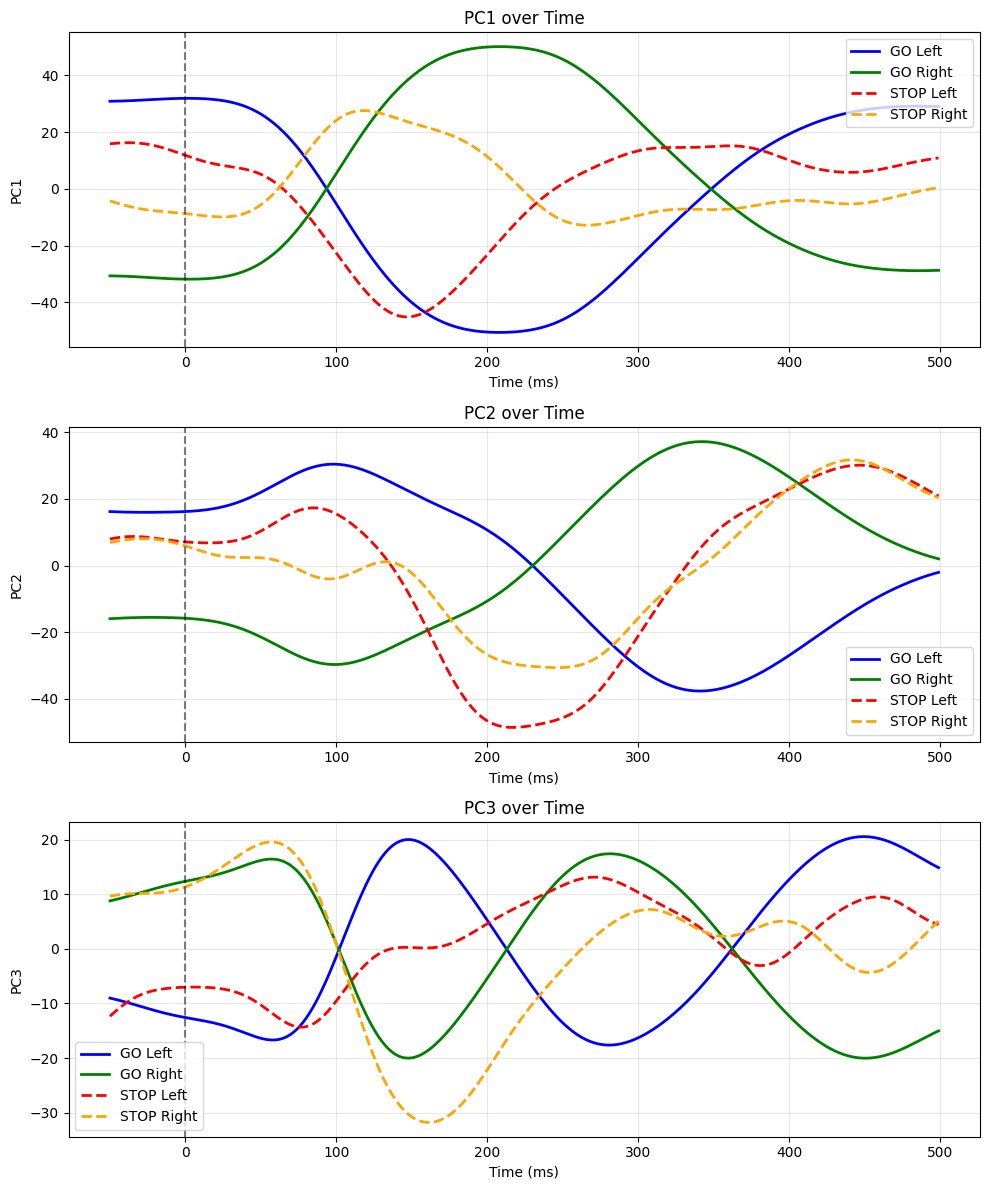

(<Figure size 1000x1200 with 3 Axes>,
 array([<Axes: title={'center': 'PC1 over Time'}, xlabel='Time (ms)', ylabel='PC1'>,
        <Axes: title={'center': 'PC2 over Time'}, xlabel='Time (ms)', ylabel='PC2'>,
        <Axes: title={'center': 'PC3 over Time'}, xlabel='Time (ms)', ylabel='PC3'>],
       dtype=object))

In [14]:
# PC time series
analyzer.plot_pc_timeseries(pcs_to_plot=[0, 1, 2])

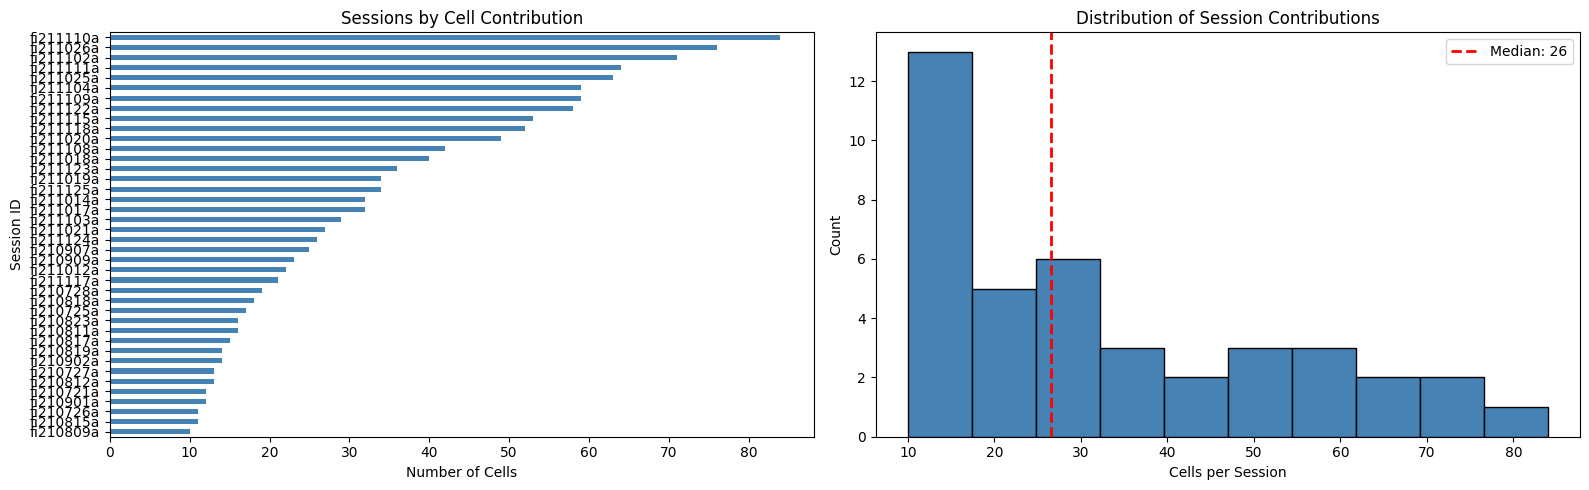

(<Figure size 1600x500 with 2 Axes>,
 array([<Axes: title={'center': 'Sessions by Cell Contribution'}, xlabel='Number of Cells', ylabel='Session ID'>,
        <Axes: title={'center': 'Distribution of Session Contributions'}, xlabel='Cells per Session', ylabel='Count'>],
       dtype=object))

In [11]:
# Session contributions
analyzer.plot_session_contributions()

In [12]:
# Print summary
analyzer.get_summary()

MULTI-SESSION PCA ANALYSIS SUMMARY

Data Summary:
  Monkey: fiona
  Sessions analyzed: 40
  Total cells: 1322

PCA Configuration:
  Epoch: [-50, 500] ms (relative to go_cue)
  Bin size: 1 ms
  Smoothing: 25 ms
  Normalization: by_baseline_FR
  Subtract average: True
  Components: 5

PCA Results:
  PC1: 48.74% variance
  PC2: 25.66% variance
  PC3: 9.56% variance
  PC4: 5.73% variance
  PC5: 3.60% variance
  Total: 93.29%


In [ ]:
# Save results
output_dir = Path.cwd().parent / 'data' / 'PCA_data' / 'multi_session_class_test'
analyzer.save_results(output_dir)

## Example 2: Custom Configuration

Customize parameters for different analyses.

In [ ]:
# Custom configuration - shorter epoch, different smoothing
custom_config = {
    'epok': [-50, 300],  # Shorter epoch
    'bin_size': 10,       # Coarser bins
    'smooth_ker_size': 50,  # More smoothing
    'n_pca_components': 3,  # Fewer components
    'subtract_average': False,  # Don't subtract average
    'min_cells_per_session': 15,  # Stricter threshold
}

analyzer2 = MultiSessionPCA(custom_config)

print("Custom Configuration:")
print(f"  Epoch: {analyzer2.config['epok']} ms")
print(f"  Bin size: {analyzer2.config['bin_size']} ms")
print(f"  Smoothing: {analyzer2.config['smooth_ker_size']} ms")
print(f"  PCA components: {analyzer2.config['n_pca_components']}")
print(f"  Min cells per session: {analyzer2.config['min_cells_per_session']}")

In [ ]:
# Run full pipeline with custom config
analyzer2.load_data(pickle_file)
analyzer2.validate_all_sessions()
analyzer2.extract_all_sessions_parallel(pickle_path=pickle_file)
analyzer2.concatenate_sessions()
analyzer2.subtract_average()  # Will skip since subtract_average=False
analyzer2.fit_and_project()
analyzer2.get_summary()

## Example 3: Chain Methods for Compact Code

Most methods return `self`, allowing method chaining.

In [ ]:
# One-liner pipeline (without extraction)
analyzer3 = (
    MultiSessionPCA()
    .load_data(pickle_file)
    .validate_all_sessions(verbose=False)
)

print(f"✓ Loaded and validated: {analyzer3.n_sessions} sessions")

## Example 4: Access Intermediate Results

All intermediate data is stored as attributes.

In [ ]:
# Access validation results
print("Validation DataFrame:")
print(analyzer.validation_df.head(10))

# Check invalid sessions
invalid = analyzer.validation_df[~analyzer.validation_df['is_valid']]
print(f"\nInvalid sessions: {len(invalid)}")
print(invalid[['session_id', 'reason']].head())

In [ ]:
# Access cell-session mapping
print("Cell-Session Mapping:")
print(analyzer.cell_session_df.head())
print(f"\nCells per session:")
print(analyzer.cell_session_df['session_id'].value_counts().head())

In [ ]:
# Access PC projections directly
print(f"GO Left PCs shape: {analyzer.go_left_PCs.shape}")
print(f"GO Right PCs shape: {analyzer.go_right_PCs.shape}")
print(f"Time axis shape: {analyzer.time.shape}")

# Access PCA object
print(f"\nPCA explained variance: {analyzer.pca.explained_variance_ratio_}")

## Example 5: Save All Plots

Generate and save all visualizations without displaying.

In [ ]:
# Create output directory
output_dir = Path.cwd().parent / 'data' / 'PCA_data' / 'multi_session_plots'
output_dir.mkdir(parents=True, exist_ok=True)

# Generate all plots (don't show, just save)
analyzer.plot_3d_trajectory(save_path=output_dir / '3d_trajectory.png', show=False)
analyzer.plot_2d_grid(save_path=output_dir / '2d_grid.png', show=False)
analyzer.plot_pc_timeseries(pcs_to_plot=[0, 1, 2], save_path=output_dir / 'pc_timeseries.png', show=False)
analyzer.plot_session_contributions(save_path=output_dir / 'session_contributions.png', show=False)

print(f"✓ All plots saved to: {output_dir}")

## Example 6: Rolling Window Analysis Preview

Demonstrates how to use the class for rolling window PCA.

In [ ]:
# Define rolling windows
window_size = 200  # ms
window_step = 50   # ms

windows = [
    [-50, 150],
    [0, 200],
    [50, 250],
    [100, 300],
]

print(f"Rolling window analysis with {len(windows)} windows:")
for i, window in enumerate(windows):
    print(f"  Window {i+1}: {window} ms")

# NOTE: Full rolling window implementation will be done separately
# This class makes it easy - just loop over windows, update config['epok'], and re-run!

In [ ]:
# Example: Analyze first window
window_config = analyzer.config.copy()
window_config['epok'] = windows[0]

window_analyzer = MultiSessionPCA(window_config)
window_analyzer.load_data(pickle_file)
window_analyzer.validate_all_sessions(verbose=False)

print(f"✓ Window 1 analyzer ready: {window_analyzer.config['epok']} ms")
print(f"  Valid sessions: {window_analyzer.n_sessions}")

## Summary

The `MultiSessionPCA` class provides:

✅ **Clean workflow**: Step-by-step pipeline with clear methods  
✅ **Flexible configuration**: Easy parameter tuning  
✅ **Reusable**: Perfect for rolling window analysis  
✅ **Transparent**: All intermediate data accessible  
✅ **Convenient**: Built-in plotting and saving  

**Next steps:**
1. Implement rolling window PCA analysis
2. Add cross-validation methods
3. Add more visualization options
4. Extend to other analysis types